# NuSmoothie + Fisher information

Simulate one event with the three learned surrogates (`NuSmoothie`), look at it, then
compute the Fisher information / angular resolution for the same event and geometry
with `FlowFisherResolutionLoss`.

Everything tunable lives in the config cell; the rest just runs.

In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '1'

import numpy as np
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import importlib
import nugget
from nugget.surrogates.NuSmoothie import NuSmoothie
from nugget.losses.fisher_info_flow import FlowFisherResolutionLoss

[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.


## Config

In [2]:
device = 'cuda:1' if torch.cuda.is_available() else 'cpu'

HIT_CKPT   = './flow_models/best_mc_hit_model_v1r.pt'
LY_CKPT    = './flow_models/best_mc_ly_muon_flow_model_v1r.pt'
ATIME_CKPT = './flow_models/best_mc_atime_muon_flow_model_v1rs.pt'





# --- surrogate / Fisher ---
N_ODE_STEPS = 16        # NuSmoothie sampling
LY_N_SAMPLES = 8        # MC samples for E[q | hit]
FISHER_N_STEPS = 4      # ODE steps inside the Fisher (memory is linear in this)
FISHER_N_QUAD  = 12     # quadrature nodes per likelihood
FISHER_CHUNK   = 512    # rows per backward; ~2 MB/row at n_steps=8 in float64

## Geometry

In [30]:
geometry = nugget.geometries.DynamicString.DynamicString(
    device=device,
    hex_type='hexagonal',
    domain_size=1200,
    dim=3,
    n_strings=200,
    points_per_string=20,
    # custom_string_spacing=100.0,
    custom_z_spacing=50.0,
)
geom_dict = geometry.initialize_points()

pts = geom_dict['points_3d'].detach().cpu().numpy()
sxy = geom_dict['string_xy'].detach().cpu().numpy()
print(f"{len(pts)} OMs on {len(sxy)} strings")
print(f"  x {pts[:,0].min():7.1f} .. {pts[:,0].max():7.1f} m")
print(f"  y {pts[:,1].min():7.1f} .. {pts[:,1].max():7.1f} m")
print(f"  z {pts[:,2].min():7.1f} .. {pts[:,2].max():7.1f} m")

4000 OMs on 200 strings
  x  -571.0 ..   600.0 m
  y  -519.6 ..   519.6 m
  z  -475.0 ..   475.0 m


## Events

`CylinderSampler` returns one dict per event with `energy`, `zenith`, `azimuth`,
`position` and `direction` — exactly the keys both `NuSmoothie` and the Fisher loss
expect, so no conversion is needed.

In [4]:
sampler = nugget.samplers.cyl_sampler.CylinderSampler(
    device=device,
    event_type='signal',
    domain_size=1200,
    E_min=1e2, E_max=1e6,
    energy_dist='log_uniform',
    uniform_zenith_sampling=False,
    random_position_along_ray=False,
    find_exact_intersection=True,
    cylinder_radius=600,
    cylinder_height=1000,
    cylinder_center=[0, 0, 0],
)

# events = sampler.sample_events(1)

# # def track_frame(ev, P):
# #     """(d_perp, d_long) of every OM w.r.t. this event's track."""
# #     z, a = float(ev['zenith']), float(ev['azimuth'])
# #     u = np.array([np.sin(z)*np.cos(a), np.sin(z)*np.sin(a), np.cos(z)])
# #     rel = P - np.asarray(ev['position'], dtype=float).reshape(1, 3)
# #     dl = rel @ u
# #     return np.linalg.norm(rel - dl[:, None] * u, axis=1), dl, u

# print(f"{'ev':>3} {'E [GeV]':>10} {'zenith':>7} {'azimuth':>8}")
# for i, ev in enumerate(events):
#     # dp, dl, _ = track_frame(ev, pts)
#     print(f"{i:>3} {float(ev['energy']):>10.3g} {float(ev['zenith']):>7.3f} "
        #   f"{float(ev['azimuth']):>8.3f} ")

## The combined surrogate

In [27]:
nusmoothie = NuSmoothie(
    device=device,
    domain_size=10000,          # overwritten per model by load_model
    hit_checkpoint=HIT_CKPT,
    ly_checkpoint=LY_CKPT,
    atime_checkpoint=ATIME_CKPT,
    n_steps=N_ODE_STEPS,
    ly_n_samples=LY_N_SAMPLES,
)

HitClassifier: context_dim=11, width=256, depth=8, params=1,060,609
FlowMatchLY: context_dim=11, width=256, depth=8, params=2,441,729
FlowMatchLY: context_dim=11, width=128, depth=6, params=514,817
NeuralSabre: particle_mode=track, patd_mode=False, pmt_mode=sum, n=1.33
  hit    context_dim= 11 device=cuda:1 dtype=torch.float64
  ly     context_dim= 11 device=cuda:1 dtype=torch.float64
  atime  context_dim= 11 device=cuda:1 dtype=torch.float64
  OM template: 16 PMT directions from /ptmp/mpp/kristiantcho/nugget/nugget/other/800_40_40_geom.csv
  all 3 models share one context (11 features) -- built once per call


## Simulate one event

`light_yield_surrogate` returns the expected photons `pi(c) . E[q | c, q>=1]` per
optical module. With the default `pmt_mode='sum'` each OM pools its 16 PMTs (the
template is read from the geometry the models were trained on); `pmt_mode='split'`
would give one entry per PMT instead.

## What it looks like

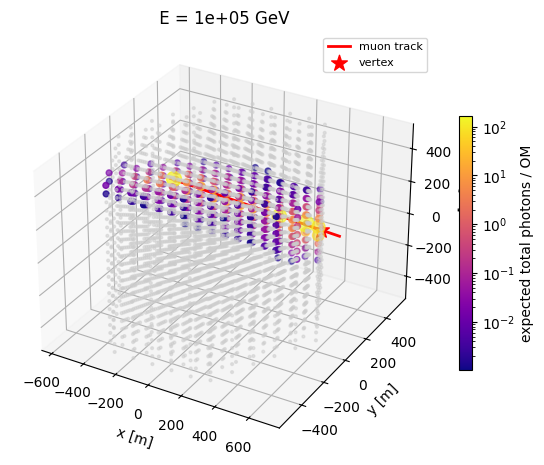

In [32]:

events = sampler.sample_events(1)

ev = events[0]
fig = plt.figure(figsize=(15, 5.5))
light_yield = nusmoothie.light_yield_surrogate(
    event_params=ev, opt_point=geom_dict['points_3d'], sample=False)
ly = light_yield.detach().cpu().numpy()
# --- 3-D view, OMs coloured by expected light ---
ax = fig.add_subplot(121, projection='3d')
dark = ly <= 1e-3
ax.scatter(pts[dark, 0], pts[dark, 1], pts[dark, 2], s=4, c='0.8', alpha=.5)
if (~dark).any():
    sc = ax.scatter(pts[~dark, 0], pts[~dark, 1], pts[~dark, 2],
                    s=18 + 120 * ly[~dark] / max(ly.max(), 1e-9),
                    c=ly[~dark], cmap='plasma', norm=plt.matplotlib.colors.LogNorm())
    fig.colorbar(sc, ax=ax, shrink=.6, label='expected total photons / OM')

v = np.asarray(ev['position'].cpu(), dtype=float).reshape(3)
u = np.array([np.sin(float(ev['zenith']))*np.cos(float(ev['azimuth'])),
              np.sin(float(ev['zenith']))*np.sin(float(ev['azimuth'])),
              np.cos(float(ev['zenith']))])
travel = -u if getattr(nusmoothie.hit_model, 'track_dir_is_arrival', False) else u
s_line = np.linspace(-800, 100, 2)
line = v[None, :] + s_line[:, None] * travel[None, :]
ax.plot(line[:, 0], line[:, 1], line[:, 2], 'r-', lw=2, label='muon track')
ax.scatter(*v, c='red', marker='*', s=140, label='vertex')
ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]'); ax.set_zlabel('z [m]')
ax.set_title(f' E = {float(ev["energy"]):.2g} GeV')
ax.legend(fontsize=8)
# change the view angle to see the track better
# ax.view_init(elev=90, azim=-0)

# --- expected light vs perpendicular distance ---
# ax2 = fig.add_subplot(122)
# # ax2.scatter(dp, np.maximum(ly, 1e-8), s=14, c=dl, cmap='viridis')
# ax2.set_xscale('log'); ax2.set_yscale('log')
# ax2.set_xlabel('perpendicular distance to track [m]')
# ax2.set_ylabel('expected photons / OM')
# ax2.set_title('light vs distance (colour = distance along track)')
# ax2.grid(alpha=.3)
# ax2 = fig.add_subplot(122, projection='3d')
# ax2.scatter(pts[dark, 0], pts[dark, 1], pts[dark, 2], s=4, c='0.8', alpha=.5)
# if (~dark).any():
#     sc = ax2.scatter(pts[~dark, 0], pts[~dark, 1], pts[~dark, 2],
#                     s=18 + 120 * ly[~dark] / max(ly.max(), 1e-9),
#                     c=ly[~dark], cmap='plasma', norm=plt.matplotlib.colors.LogNorm())
#     fig.colorbar(sc, ax=ax2, shrink=.6, label='expected photons / OM')
# ax2.plot(line[:, 0], line[:, 1], line[:, 2], 'r-', lw=2, label='muon track')
# ax2.scatter(*v, c='red', marker='*', s=140, label='vertex')
# ax2.set_xlabel('x [m]'); ax2.set_ylabel('y [m]'); ax2.set_zlabel('z [m]')
# # ax2.set_title(f'E = {float(ev["energy"]):.2g} GeV')
# ax2.legend(fontsize=8)
# # change the view angle to see the track better
# ax2.view_init(elev=0, azim=-0)
plt.show()

## Arrival times

`patd_mode=True` returns one dict per optical module in `LightSabrePATD`'s format:
`hit_times`, `residual_times`, `geometric_times`, `num_photons`, `expected_photons`,
`emission_points`, `d_geom`, `t_geom_min`, `vertex_times`, `patd_probs`.

61 OMs fired, 735 photons in total


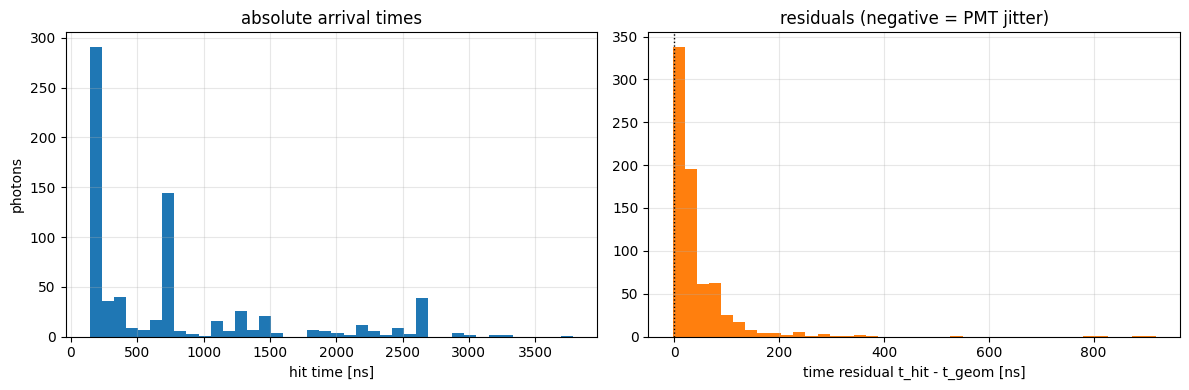

  t_res: p16/p50/p84 = [ 3.15 20.78 70.94] ns, frac < 0 = 0.003


In [33]:
patd = nusmoothie.light_yield_surrogate(
    event_params=ev, opt_point=geom_dict['points_3d'], patd_mode=True)
if isinstance(patd, dict):
    patd = [patd]

lit = [(i, d) for i, d in enumerate(patd) if d['num_photons'] > 0]
n_ph = sum(d['num_photons'] for _, d in lit)
print(f'{len(lit)} OMs fired, {n_ph} photons in total')

if n_ph:
    t_hit = torch.cat([d['hit_times'] for _, d in lit]).detach().cpu().numpy()
    t_res = torch.cat([d['residual_times'] for _, d in lit]).detach().cpu().numpy()
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].hist(t_hit, bins=40, color='C0')
    ax[0].set_xlabel('hit time [ns]'); ax[0].set_ylabel('photons')
    ax[0].set_title('absolute arrival times'); ax[0].grid(alpha=.3)
    ax[1].hist(t_res, bins=40, color='C1')
    ax[1].axvline(0, color='k', ls=':', lw=1)
    ax[1].set_xlabel('time residual t_hit - t_geom [ns]')
    ax[1].set_title('residuals (negative = PMT jitter)'); ax[1].grid(alpha=.3)
    plt.tight_layout(); plt.show()
    print(f'  t_res: p16/p50/p84 = {np.percentile(t_res, [16, 50, 84]).round(2)} ns, '
          f'frac < 0 = {np.mean(t_res < 0):.3f}')
else:
    print('nothing fired -- move the event closer to the array, raise the energy, '
          'or make the geometry denser')

## Fisher information

Per PMT the three likelihoods contribute independent Fisher matrices that add:

```
F_j = pi (1-pi) grad l grad l^T           (hit, closed form)
    + pi      E_q[ grad log p_q ... ]     (light yield)
    + pi qbar E_t[ grad log p_t ... ]     (arrival time)
```

summed over PMTs, then over strings. `mode='atime'` keeps only the third term but
still evaluates `pi` and `qbar`, since they weight it.

Memory is the thing to watch: the differentiable log-prob holds `FISHER_N_STEPS`
forward + double-backward passes per row, about 2 MB/row in float64. Keep
`fisher_info_chunk_size` small enough that `chunk x 2 MB` fits on the card.

In [56]:
importlib.reload(nugget.losses.fisher_info_flow)
N_ODE_STEPS = 16        # NuSmoothie sampling
LY_N_SAMPLES = 8        # MC samples for E[q | hit]
FISHER_N_STEPS = 8      # ODE steps inside the Fisher (memory is linear in this)
FISHER_N_QUAD  = 25     # quadrature nodes per likelihood
FISHER_CHUNK   = 5000    # rows per backward; ~2 MB/row at n_steps=8 in float64
fisher_loss = FlowFisherResolutionLoss(
    hit_model=nusmoothie.hit_model,
    ly_model=nusmoothie.ly_model,
    atime_model=nusmoothie.atime_model,
    device=device,
    fisher_info_params=('energy', 'zenith', 'azimuth'),
    resolution_type='angular',
    mode='all',
    n_quad=FISHER_N_QUAD,
    n_steps=FISHER_N_STEPS,
    print_loss=True,
    sample_hits=True,
    n_hit_samples=1000,
)

out = fisher_loss(
    geom_dict,
    # signal_sampler=sampler,
    # num_events=100,
    signal_event_params=[ev],
    fisher_info_chunk_size=FISHER_CHUNK,
    fisher_res_metric='mean',
    verbose=True,
    empty_cache_after_event=False
)

F = out['fisher_info_per_string_per_event']          # (n_events, n_strings, 3, 3)
res_deg = np.degrees(out['angular_resolution_per_event'].detach().cpu().numpy())
print(f"\nFisher per string per event: {tuple(F.shape)}")
print(f"angular resolution: {res_deg[0]:.3f} deg")

F_tot = F.sum(1)[0].detach().cpu().numpy()
print('\ntotal Fisher matrix (log10E, zenith, azimuth):')
print(np.array2string(F_tot, precision=3, suppress_small=False))
print('eigenvalues:', np.linalg.eigvalsh(F_tot).round(4))

  Fisher: event 1/1
FlowFisherResolutionLoss[all]: 0.0782426 (1/1 events usable)

Fisher per string per event: (1, 200, 3, 3)
angular resolution: 4.483 deg

total Fisher matrix (log10E, zenith, azimuth):
[[ 54.177 -37.588 -26.172]
 [-37.588 242.528 -37.419]
 [-26.172 -37.419 970.412]]
eigenvalues: [ 45.7853 248.3607 972.9702]


In [87]:
import gc
gc.collect()
torch.cuda.empty_cache()

## All events, and the arrival-time-only mode

In [127]:
fisher_atime = FlowFisherResolutionLoss(
    hit_model=nusmoothie.hit_model,
    ly_model=nusmoothie.ly_model,
    atime_model=nusmoothie.atime_model,
    device=device, mode='atime',
    n_quad=FISHER_N_QUAD, n_steps=FISHER_N_STEPS,
)

out_all = fisher_loss(geom_dict, signal_event_params=events,
                      fisher_info_chunk_size=FISHER_CHUNK)
out_at  = fisher_atime(geom_dict, signal_event_params=events,
                       fisher_info_chunk_size=FISHER_CHUNK)

r_all = np.degrees(out_all['angular_resolution_per_event'].detach().cpu().numpy())
r_at  = np.degrees(out_at['angular_resolution_per_event'].detach().cpu().numpy())

print(f"{'ev':>3} {'E [GeV]':>10} {'min d_perp':>11} {'all [deg]':>11} "
      f"{'atime [deg]':>12} {'atime/all':>10}")
for i, ev_i in enumerate(events):
#     dpi, _, _ = track_frame(ev_i, pts)
    print(f"{i:>3} {float(ev_i['energy']):>10.3g} "
          f"{r_all[i]:>11.3f} {r_at[i]:>12.3f} {r_at[i]/r_all[i]:>10.3f}")
print(f"\ncombined (fom): all = {float(out_all['angular_resolution_loss']):.4g} rad, "
      f"atime = {float(out_at['angular_resolution_loss']):.4g} rad")

FlowFisherResolutionLoss[all]: 0.0747982 (1/1 events usable)
 ev    E [GeV]  min d_perp   all [deg]  atime [deg]  atime/all
  0   1.29e+03       4.286        4.288      1.001

combined (fom): all = 0.0748 rad, atime = 0.07485 rad
